In [ ]:
import numpy as np, matplotlib.pyplot as plt, itertools, time
from tqdm import tqdm
from scipy.special import comb
import stim

from lib.entropic_measure import (
    Lattice2D,
    make_surface_code_lattice,
    index_to_pauli_string,
    error_distribution_func_1q,
    make_joint_distribution,
    calculate_conditional_entropy_logical_on_stabilizer,
    calculate_logical_entropy,
)
from lib.entropic_measure_fast import (
    Compass2DLattice, 
    generate_errors_by_weight, 
    get_joint_distribution,
    generate_errors_square_lattice,
    compute_cond_entropy,
    compute_entropy,
)
from lib.color_compass import pauli2vector, twisted_prod_mat
# from lib.color_compass import bacon_shor_group, bsgauge_group, pauli2vector, pauli_weight, twisted_product, twisted_prod_mat
# from termcolor import colored


# plt.rc('font',**{'family':'serif','serif':['Helvetica'],'size':20})
plt.rc('font',**{'size':18})
plt.rc('text', usetex=True)

: 

# Fast Compass2DLattice

## Verify stabilizer generation

In [2]:
dimX, dimZ = 7, 7

for _ in range(100):
    colors = np.random.choice([-1, 0, 1], (dimX-1)*(dimZ-1))
    lat1 = Lattice2D(dimX, dimZ)
    lat1.color_lattice(colors)
    lat2 = Compass2DLattice(dimX, dimZ)
    lat2.color_lattice(colors)
    
    assert set(lat1.getSx()) == set(lat2.getSx())
    assert set(lat1.getSz()) == set(lat2.getSz())
print('Lattice2D and Compass2DLattice agree on stabilizers')

Lattice2D and Compass2DLattice agree on stabilizers


## Runtime comparison

In [119]:
# dimX, dimZ = 4, 4

# colors = np.random.choice([-1, 0, 1], (dimX-1)*(dimZ-1))
# lat1 = Lattice2D(dimX, dimZ)
# lat2 = Compass2DLattice(dimX, dimZ)

# %timeit -n 100 lat1.color_lattice(colors)
# %timeit lat2.color_lattice(colors)


2.19 ms ± 65.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
99.3 µs ± 4.99 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [121]:
# t_means = []
# t_stds = []
# dims = np.arange(3, 10)
# for dim in dims:
#     lat1 = Lattice2D(dim, dim)
#     lat2 = Compass2DLattice(dim, dim)
#     colors = np.random.choice([-1, 0, 1], (dim-1)*(dim-1))

#     result1 = %timeit -o -n 100 lat1.color_lattice(colors)
#     result2 = %timeit -o lat2.color_lattice(colors)

#     t_means.append([result1.average, result2.average])
#     t_stds.append([result1.stdev, result2.stdev])
# t_means = np.array(t_means)
# t_stds = np.array(t_stds)

432 µs ± 21.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
46 µs ± 4.64 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
1.66 ms ± 109 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
85 µs ± 1.48 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
4.7 ms ± 65.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
158 µs ± 6.22 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
15.2 ms ± 294 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
280 µs ± 3.51 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
37.1 ms ± 1.05 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
459 µs ± 19.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
76.3 ms ± 1.05 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
748 µs ± 34.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
150 ms ± 2.52 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.05 ms ± 34.2 µs per loop (mean ± std. dev. of 7 runs, 1,000 

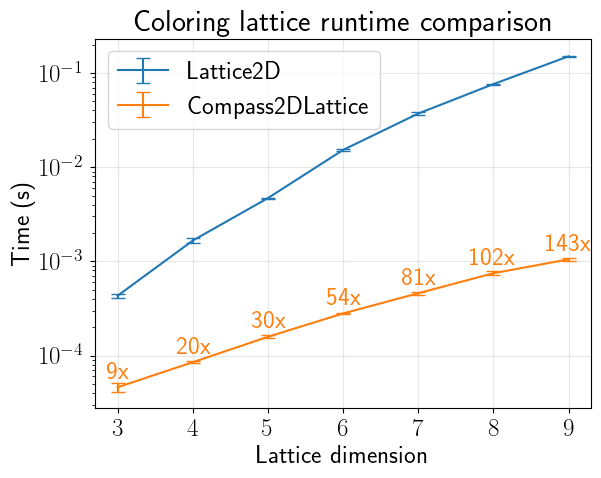

In [139]:
# dims = np.arange(3, 10)

# plt.errorbar(dims, t_means[:,0], yerr=t_stds[:,0], capsize=5, label='Lattice2D')
# plt.errorbar(dims, t_means[:,1], yerr=t_stds[:,1], capsize=5, label='Compass2DLattice')
# improvements = t_means[:,0] / t_means[:,1]
# for i in range(len(dims)):
#     plt.text(dims[i], t_means[i,1]*1.1, f'{round(improvements[i])}x', ha='center', va='bottom', color='C1')
# plt.xticks(dims)
# plt.yscale('log')
# plt.xlabel('Lattice dimension')
# plt.ylabel('Time (s)')
# plt.title('Coloring lattice runtime comparison')
# plt.legend()
# plt.grid(alpha=0.3)

# Convert to tableau

In [16]:
dimX, dimZ = 3, 3

colors = np.random.choice([-1, 0, 1], (dimX-1)*(dimZ-1))
lat = Compass2DLattice(dimX, dimZ)
lat.color_lattice(colors)
print(lat)
lat.getS()

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



['X__X_____',
 '_XX_XX___',
 '___XXXXXX',
 'ZZ_ZZ____',
 '______ZZ_',
 '_ZZ______',
 '____ZZ___',
 '_______ZZ']

In [17]:
lat.parity_check_matrix()

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]])

In [7]:
# show the parity check matrix
parity_check_matrix = lat.parity_check_matrix()
parity_check_matrix

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0]])

In [2]:
def error_distribution_func(pauli_string, px, py, pz):
    probs = {'I': 1-px-py-pz, 'X': px, 'Y': py, 'Z': pz}
    # prob is the joint probability of the error string
    prob = 1
    for p in pauli_string:
        prob *= probs[p]
    return prob

def calculate_stabilizer_entropy_exact(parity_check_mat, error_distribution_func, error_rates):
    N = parity_check_mat.shape[1]/2
    # assert num_qubits == int(num_qubits)
    num_qubits = int(N)
    syndrome_weight_dict = {}
    for i in tqdm(range(4**num_qubits)):
        pauli_string = index_to_pauli_string(i, num_qubits)
        pauli_bitstring = pauli2vector(pauli_string)
        syndrome = twisted_prod_mat(parity_check_mat, pauli_bitstring)
        syndrome_string = ''.join([str(int(s)) for s in syndrome])
        prob = error_distribution_func(pauli_string, *error_rates)
        if syndrome_string in syndrome_weight_dict.keys():
            syndrome_weight_dict[syndrome_string] += prob
        else:
            syndrome_weight_dict[syndrome_string] = prob
    return -np.sum([p*np.log2(p) for p in syndrome_weight_dict.values()])

def random_pauli(rates):
    p_i = 1-sum(rates)
    return np.random.choice(['I', 'X', 'Y', 'Z'], p=[p_i, rates[0], rates[1], rates[2]])

def calculate_stabilizer_entropy_emperical(parity_check_mat, error_distribution_func, error_rates, num_samples):
    num_qubits = parity_check_mat.shape[1]/2
    assert num_qubits == int(num_qubits)
    num_qubits = int(num_qubits)
    syndrome_weight_dict = {}
    for i in range(num_samples):
        pauli_string = ''.join([random_pauli(error_rates) for _ in range(num_qubits)])
        pauli_bitstring = pauli2vector(pauli_string)
        syndrome = twisted_prod_mat(parity_check_mat, pauli_bitstring)
        syndrome_string = ''.join([str(int(s)) for s in syndrome])
        if syndrome_string in syndrome_weight_dict.keys():
            syndrome_weight_dict[syndrome_string] += 1/num_samples
        else:
            syndrome_weight_dict[syndrome_string] = 1/num_samples
    return -np.sum([p*np.log2(p) for p in syndrome_weight_dict.values()])

In [20]:
4**9

262144

In [22]:
parity_check_matrix = lat.parity_check_matrix()
rates = [0.01, 0.01, 0.05]
calculate_stabilizer_entropy_exact(parity_check_matrix, error_distribution_func, rates)

100%|██████████| 262144/262144 [00:06<00:00, 38335.78it/s]


3.105688937530993

In [24]:
parity_check_mat = lat.parity_check_matrix()
error_rates = [0.01, 0.01, 0.05]


num_qubits = parity_check_mat.shape[1]/2
assert num_qubits == int(num_qubits)
num_qubits = int(num_qubits)
syndrome_weight_dict = {}
for i in tqdm(range(4**num_qubits)):
    pauli_string = index_to_pauli_string(i, num_qubits)
    pauli_bitstring = pauli2vector(pauli_string)
    syndrome = twisted_prod_mat(parity_check_mat, pauli_bitstring)
    syndrome_string = ''.join([str(int(s)) for s in syndrome])
    prob = error_distribution_func(pauli_string, *error_rates)
    if syndrome_string in syndrome_weight_dict.keys():
        syndrome_weight_dict[syndrome_string] += prob
    else:
        syndrome_weight_dict[syndrome_string] = prob

100%|██████████| 262144/262144 [00:07<00:00, 36501.57it/s]


In [26]:
syndrome

array([0, 0, 0, 0, 0, 0, 0, 0])

# Fast error partition

## Verify joint_distribution

In [ ]:
d = 3
rates = [0.1, 0.1, 0.1]
lat = make_surface_code_lattice(d,d)
print(lat)

# old code
joint_distribution = make_joint_distribution(lat, rates)

# fast code
error_strs, error_vecs = generate_errors_by_weight(d*d, 0, d*d)
error_probs = np.array([error_distribution_func_1q(p, rates) for p in error_strs])
joint_dist = get_joint_distribution(lat, error_vecs, error_probs, axes='LXZ')

abs(joint_distribution - joint_dist).max()

[1, -1, -1, 1]
000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



100%|██████████| 262144/262144 [00:27<00:00, 9406.32it/s]


4.3021142204224816e-16

In [ ]:
d = 3
rates = [0.2, 0.05, 0.1]
lat = Compass2DLattice(d,d)
lat.make_surface()
print(lat)

# old code
joint_distribution = make_joint_distribution(lat, rates)

# fast code
error_strs, error_vecs = generate_errors_by_weight(d*d, 0, d*d)
error_probs = np.array([error_distribution_func_1q(p, rates) for p in error_strs])
joint_dist = get_joint_distribution(lat, error_vecs, error_probs, axes='LXZ')

abs(joint_distribution - joint_dist).max()

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



100%|██████████| 262144/262144 [00:27<00:00, 9522.40it/s]


1.214306433183765e-16

In [ ]:
d = 3
rates = 0.1*np.random.rand(3)

lat = Compass2DLattice(d,d)
colors = np.random.choice([-1, 0, 1], len(lat.colors))
lat.color_lattice(colors)
print(rates)
print(lat)

# old code
joint_distribution = make_joint_distribution(lat, rates)

# fast code
error_strs, error_vecs = generate_errors_by_weight(d*d, 0, d*d)
error_probs = np.array([error_distribution_func_1q(p, rates) for p in error_strs])
joint_dist = get_joint_distribution(lat, error_vecs, error_probs, axes='LXZ')

abs(joint_distribution - joint_dist).max()

[0.03337948 0.04890739 0.01843543]
000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



100%|██████████| 262144/262144 [00:28<00:00, 9295.68it/s]


1.887379141862766e-15

## Runtime comparison
- d = 3: 10x faster
- d = 4: would've taken 200hrs+

In [4]:
# rates = [0.2, 0.05, 0.1]
rates = [0.1, 0.1, 0.1]
print('Estimate times for d = 3, 4, 5')
for d in range(3,6):
    lat = Compass2DLattice(d,d)
    lat.make_surface()
    if d == 3:
        joint_distribution = make_joint_distribution(lat, rates)
    else:
        joint_distribution = make_joint_distribution(lat, rates, auto_break=True)

Estimate times for d = 3, 4, 5


  0%|          | 50001/1125899906842624 [00:14<93762387:56:13, 3335.56it/s] 


In [11]:
d = 3
lat = Compass2DLattice(d,d)
lat.make_surface()
print(lat)

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



In [12]:
%%timeit
# fast code
error_strs, error_vecs = generate_errors_by_weight(d*d, 0, d*d)
error_probs = np.array([error_distribution_func_1q(p, rates) for p in error_strs])
joint_dist = get_joint_distribution(lat, error_vecs, error_probs, axes='LXZ')

2.02 s ± 11.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Fast entropy estimation on smaller error set

In [ ]:
# rates = [1e-3]*3
# rates = [0.01, 0.02, 0.1]
# rates = [0.2, 0.2, 0.2]
# d = 3
# Estrs_all, Evecs_all, Eprobs_all = generate_errors_square_lattice(d, rates, 'all')
# Estrs_detect, Evecs_detect, Eprobs_detect = generate_errors_square_lattice(d, rates, 'detectable')
# Estrs_most, Evecs_most, Eprobs_most = generate_errors_square_lattice(d, rates, 'most_probable')

# print(f'{len(Estrs_all)}: {Eprobs_all.sum()}')
# print(f'{len(Estrs_detect)}: {Eprobs_detect.sum()}')
# print(f'{len(Estrs_most)}: {Eprobs_most.sum()}')

## Performance vs. rate

In [15]:
d = 3
error_rates = np.logspace(-4, -1, 10)
error_sets = ['all', 'detectable', 'most_probable']

lat = Compass2DLattice(d,d)
lat.make_surface()
print(lat)

counts = np.zeros((len(error_rates), 3), dtype=int)
covered_probs = np.zeros((len(error_rates), 3))
Hconds = np.zeros((len(error_rates), 3))
Hlogicals = np.zeros((len(error_rates), 3))
times = np.zeros((len(error_rates), 3))
error_partition_times = np.zeros((len(error_rates), 3))

for i, error_rate in enumerate(tqdm(error_rates)):
# for i, error_rate in enumerate(error_rates):
# for error_rate in [0.1]:
    rates = [error_rate]*3
    for j, error_set in enumerate(error_sets):
        start = time.time()
        Es = generate_errors_square_lattice(d, rates, error_set)

        start_error_partition = time.time()
        joint_dist = get_joint_distribution(lat, Es[1], Es[2], axes='LXZ')
        Hconds[i,j] = compute_cond_entropy(joint_dist, axis=0)
        Hlogicals[i,j] = compute_entropy(joint_dist.sum(axis=(1,2)))    

        end = time.time()

        counts[i,j] = len(Es[0])
        covered_probs[i,j] = Es[2].sum()
        times[i,j] = end-start
        error_partition_times[i,j] = end-start_error_partition
        # break
    # break


000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



100%|██████████| 10/10 [00:24<00:00,  2.40s/it]


In [7]:
Hconds

array([[9.06892319e-06, 9.05106720e-06, 9.05106720e-06],
       [3.92083818e-05, 3.90437837e-05, 3.90437837e-05],
       [1.68548956e-04, 1.67044811e-04, 1.67093714e-04],
       [7.19465811e-04, 7.05885091e-04, 7.13516956e-04],
       [3.04240978e-03, 2.92200089e-03, 3.01519845e-03],
       [1.26853880e-02, 1.16494750e-02, 1.25748120e-02],
       [5.15804345e-02, 4.31394867e-02, 5.11405806e-02],
       [1.98733788e-01, 1.36854503e-01, 1.97200121e-01],
       [6.70330489e-01, 3.06131226e-01, 6.64064403e-01],
       [1.60359189e+00, 2.77907094e-01, 1.58171886e+00]])

In [306]:
counts

array([[262144,    352,    352],
       [262144,    352,    352],
       [262144,    352,    453],
       [262144,    352,   1613],
       [262144,    352,   2160],
       [262144,    352,   2435],
       [262144,    352,   2609],
       [262144,    352,  10556],
       [262144,    352,  28768],
       [262144,    352,  88036]])

Text(0.5, 0.95, 'Estimating entropy measure for $d=3$')

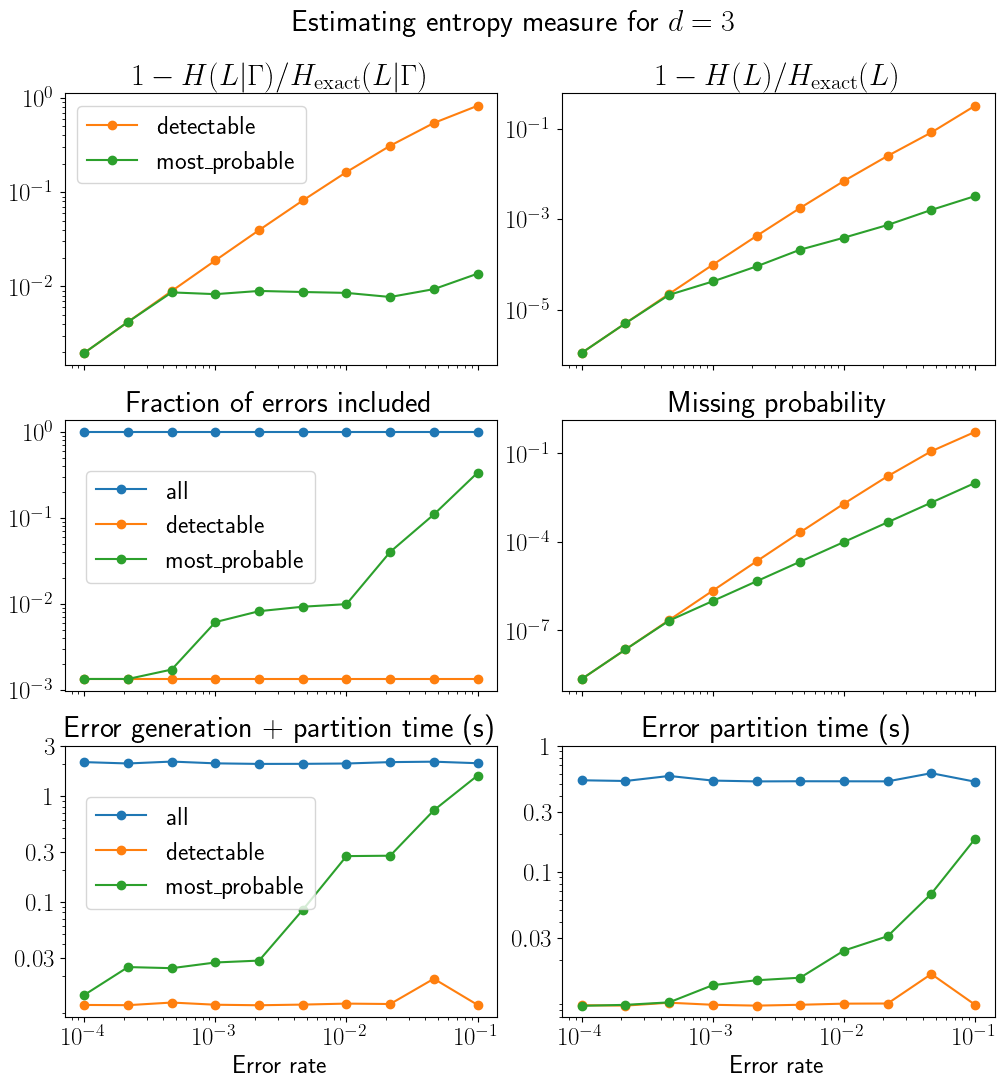

In [8]:
fig, axs = plt.subplots(3, 2, figsize=(12,12), sharex=True, gridspec_kw={'hspace': 0.2, 'wspace': 0.15})
for i, label in enumerate(error_sets):
    # axs[0,0].plot(error_rates, Hconds[:,i], f'C{i}o-', label=label)
    if i != 0:
        axs[0,0].plot(error_rates, 1-Hconds[:,i]/Hconds[:,0], f'C{i}o-', label=label)
        axs[0,1].plot(error_rates, 1-Hlogicals[:,i]/Hlogicals[:,0], f'C{i}o-', label=label)
        axs[1,1].plot(error_rates, 1-covered_probs[:,i], f'C{i}o-', label=label)
    axs[1,0].plot(error_rates, counts[:,i]/counts[:,0], f'C{i}o-', label=label)
    axs[2,0].plot(error_rates, times[:,i], f'C{i}o-', label=label)
    axs[2,1].plot(error_rates, error_partition_times[:,i], f'C{i}o-', label=label)
axs[0,0].set_title('$1-H(L|\Gamma)/H_{\\rm exact}(L|\Gamma)$')
axs[0,1].set_title('$1-H(L)/H_{\\rm exact}(L)$')
axs[1,0].set_title('Fraction of errors included')
axs[1,1].set_title('Missing probability')
axs[2,0].set_title('Error generation + partition time (s)')
axs[2,1].set_title('Error partition time (s)')
axs[2,0].set_xlabel('Error rate')
axs[2,1].set_xlabel('Error rate')
for ax in axs.flatten():
    ax.set_yscale('log')
axs[0,0].set_xscale('log')
axs[0,0].legend(loc='upper left')
axs[1,0].legend(loc=(0.05,0.4))
axs[2,0].legend(loc=(0.05,0.4))
axs[2,0].set_yticks([0.03,0.1,0.3,1,3])
axs[2,0].set_yticklabels([f'${x}$' for x in [0.03,0.1,0.3,1,3]])
axs[2,1].set_yticks([0.03,0.1,0.3,1])
axs[2,1].set_yticklabels([f'${x}$' for x in [0.03,0.1,0.3,1]])


fig.suptitle(f'Estimating entropy measure for $d={d}$', y=0.95)

Text(0.5, 0.95, 'Estimating entropy measure for $d=3$')

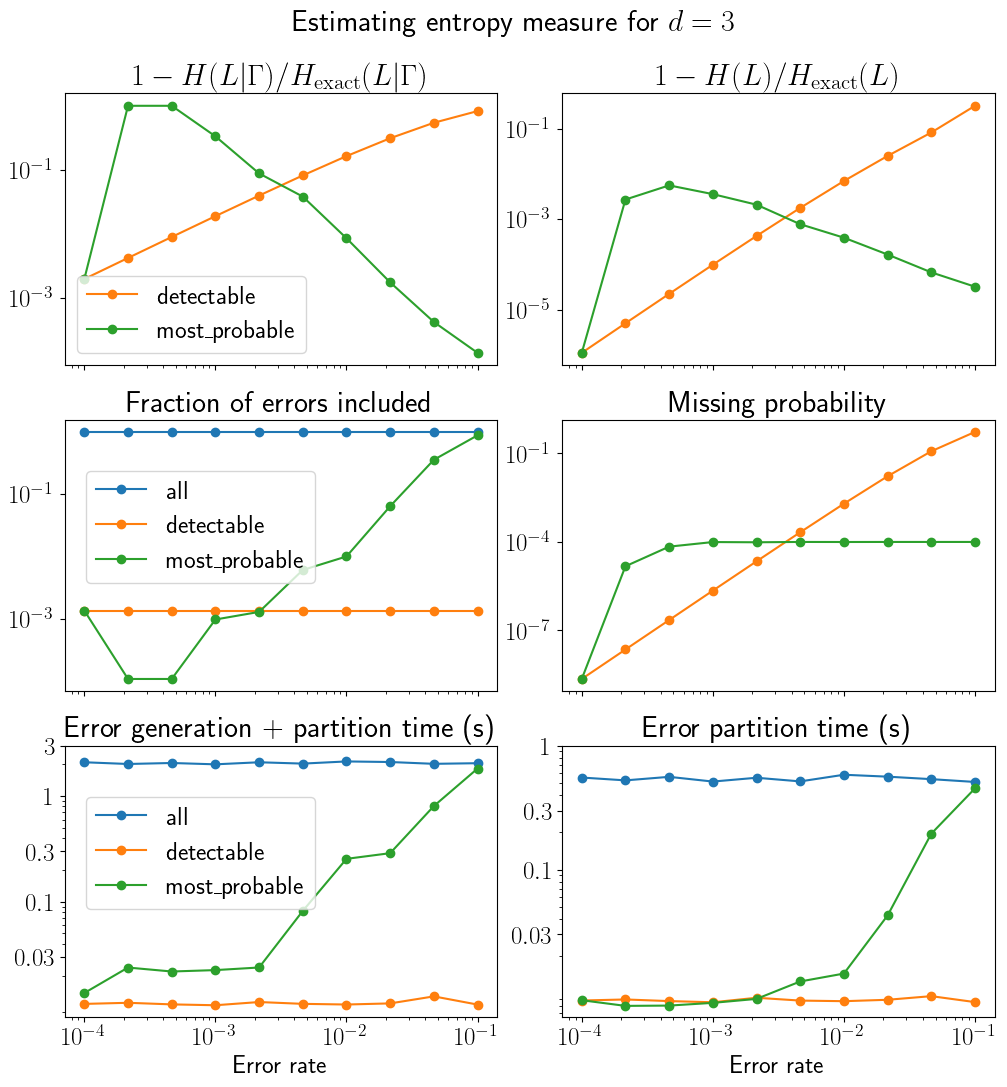

In [23]:
fig, axs = plt.subplots(3, 2, figsize=(12,12), sharex=True, gridspec_kw={'hspace': 0.2, 'wspace': 0.15})
for i, label in enumerate(error_sets):
    # axs[0,0].plot(error_rates, Hconds[:,i], f'C{i}o-', label=label)
    if i != 0:
        axs[0,0].plot(error_rates, 1-Hconds[:,i]/Hconds[:,0], f'C{i}o-', label=label)
        axs[0,1].plot(error_rates, 1-Hlogicals[:,i]/Hlogicals[:,0], f'C{i}o-', label=label)
        axs[1,1].plot(error_rates, 1-covered_probs[:,i], f'C{i}o-', label=label)
    axs[1,0].plot(error_rates, counts[:,i]/counts[:,0], f'C{i}o-', label=label)
    axs[2,0].plot(error_rates, times[:,i], f'C{i}o-', label=label)
    axs[2,1].plot(error_rates, error_partition_times[:,i], f'C{i}o-', label=label)
axs[0,0].set_title('$1-H(L|\Gamma)/H_{\\rm exact}(L|\Gamma)$')
axs[0,1].set_title('$1-H(L)/H_{\\rm exact}(L)$')
axs[1,0].set_title('Fraction of errors included')
axs[1,1].set_title('Missing probability')
axs[2,0].set_title('Error generation + partition time (s)')
axs[2,1].set_title('Error partition time (s)')
axs[2,0].set_xlabel('Error rate')
axs[2,1].set_xlabel('Error rate')
for ax in axs.flatten():
    ax.set_yscale('log')
axs[0,0].set_xscale('log')
axs[0,0].legend(loc='lower left')
axs[1,0].legend(loc=(0.05,0.4))
axs[2,0].legend(loc=(0.05,0.4))
axs[2,0].set_yticks([0.03,0.1,0.3,1,3])
axs[2,0].set_yticklabels([f'${x}$' for x in [0.03,0.1,0.3,1,3]])
axs[2,1].set_yticks([0.03,0.1,0.3,1])
axs[2,1].set_yticklabels([f'${x}$' for x in [0.03,0.1,0.3,1]])


fig.suptitle(f'Estimating entropy measure for $d={d}$', y=0.95)

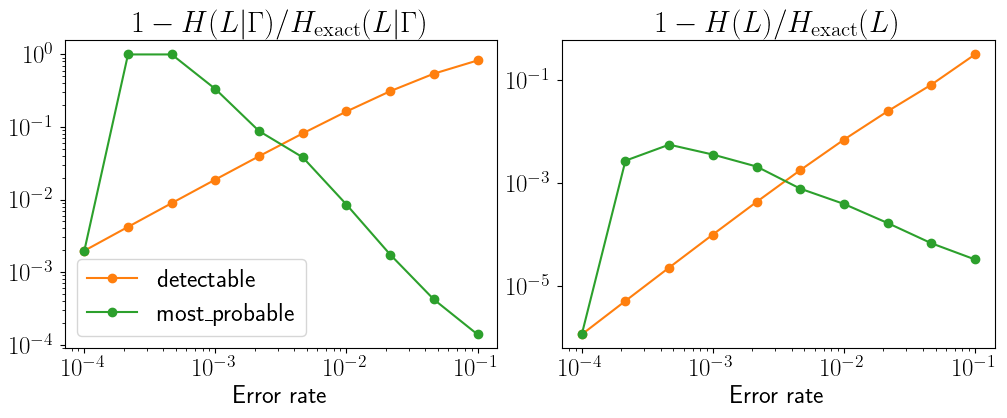

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12,4), sharex=True, gridspec_kw={'hspace': 0.2, 'wspace': 0.15})
for i, label in enumerate(error_sets):
    # axs[0,0].plot(error_rates, Hconds[:,i], f'C{i}o-', label=label)
    if i != 0:
        axs[0].plot(error_rates, 1-Hconds[:,i]/Hconds[:,0], f'C{i}o-', label=label)
        axs[1].plot(error_rates, 1-Hlogicals[:,i]/Hlogicals[:,0], f'C{i}o-', label=label)
axs[0].set_title('$1-H(L|\Gamma)/H_{\\rm exact}(L|\Gamma)$')
axs[1].set_title('$1-H(L)/H_{\\rm exact}(L)$')
axs[0].set_xlabel('Error rate')
axs[1].set_xlabel('Error rate')
for ax in axs.flatten():
    ax.set_yscale('log')
axs[0].set_xscale('log')
axs[0].legend(loc='lower left')

# fig.suptitle(f'Estimating entropy measure for $d={d}$', y=0.95)

In [40]:
Hlogicals

array([[1.93138979, 1.3164553 , 1.93132736],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ]])

## Compare surface with shor codes 

### d = 3

In [29]:
d = 3

# define some lattices to compare
lat_surface = Compass2DLattice(d,d)
lat_surface.make_surface()
lat_shor_blue = Compass2DLattice(d,d)
lat_shor_blue.color_lattice([1]*len(lat_shor_blue.colors))
lat_shor_red = Compass2DLattice(d,d)
lat_shor_red.color_lattice([-1]*len(lat_shor_red.colors))
print(lat_surface)
print(lat_shor_blue)
print(lat_shor_red)

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008

000---001---002
 |  #  |  #  |
003---004---005
 |  #  |  #  |
006---007---008



In [19]:
lat_shor_blue.getS()

['X__X_____',
 '_X__X____',
 '__X__X___',
 '___X__X__',
 '____X__X_',
 '_____X__X',
 'ZZ_ZZ_ZZ_',
 '_ZZ_ZZ_ZZ']

In [30]:
lat_labels = ['Surface', 'Shor blue (detect Z best)', 'Shor red (detect X best)']
error_sets = ['all', 'detectable', 'most_probable']
rates_labels = ['Depol', 'X dominated', 'Y dominated', 'Z dominated']
for i_rate, rates in enumerate(
    [[0.1, 0.1, 0.1], [0.1, 0.03, 0.01], [0.01, 0.1, 0.03], [0.03, 0.01, 0.1]]):
    Es_by_errorset = {
        error_set: generate_errors_square_lattice(d, rates, error_set)
        for error_set in error_sets
    }

    counts = np.zeros((len(error_sets), 3), dtype=int)
    covered_probs = np.zeros((len(error_sets), 3))
    Hconds = np.zeros((len(error_sets), 3))
    Hlogicals = np.zeros((len(error_sets), 3))

    for i, error_set in enumerate(tqdm(error_sets)):
        for j, lat in enumerate([lat_surface, lat_shor_blue, lat_shor_red]):
            Es = Es_by_errorset[error_set]
            joint_dist = get_joint_distribution(lat, Es[1], Es[2], axes='LXZ')
            Hconds[i,j] = compute_cond_entropy(joint_dist, axis=0)
            Hlogicals[i,j] = compute_entropy(joint_dist.sum(axis=(1,2)))    
            counts[i,j] = len(Es[0])
            covered_probs[i,j] = Es[2].sum()

    print(f'\n[px, py, pz] = {rates}, {rates_labels[i_rate]}')
    for i, error_set in enumerate(error_sets):
        print(f'\n--- {error_set} ---')
        for j, lat in enumerate([lat_surface, lat_shor_blue, lat_shor_red]):
            print(f'{lat_labels[j].ljust(26)}:  {Hconds[i,j]:.3f},  {Hlogicals[i,j]:.3f}')

100%|██████████| 3/3 [00:02<00:00,  1.29it/s]



[px, py, pz] = [0.1, 0.1, 0.1], Depol

--- all ---
Surface                   :  1.604,  1.931
Shor blue (detect Z best) :  1.582,  1.931
Shor red (detect X best)  :  1.582,  1.931

--- detectable ---
Surface                   :  0.278,  1.316
Shor blue (detect Z best) :  0.266,  1.316
Shor red (detect X best)  :  0.266,  1.316

--- most_probable ---
Surface                   :  1.582,  1.925
Shor blue (detect Z best) :  1.560,  1.925
Shor red (detect X best)  :  1.560,  1.925


100%|██████████| 3/3 [00:01<00:00,  1.74it/s]



[px, py, pz] = [0.1, 0.03, 0.01], X dominated

--- all ---
Surface                   :  0.629,  1.376
Shor blue (detect Z best) :  0.666,  1.376
Shor red (detect X best)  :  0.581,  1.376

--- detectable ---
Surface                   :  0.328,  1.279
Shor blue (detect Z best) :  0.390,  1.279
Shor red (detect X best)  :  0.251,  1.279

--- most_probable ---
Surface                   :  0.594,  1.363
Shor blue (detect Z best) :  0.632,  1.363
Shor red (detect X best)  :  0.544,  1.363


100%|██████████| 3/3 [00:01<00:00,  1.72it/s]



[px, py, pz] = [0.01, 0.1, 0.03], Y dominated

--- all ---
Surface                   :  0.520,  1.695
Shor blue (detect Z best) :  0.557,  1.695
Shor red (detect X best)  :  0.492,  1.695

--- detectable ---
Surface                   :  0.203,  1.570
Shor blue (detect Z best) :  0.229,  1.570
Shor red (detect X best)  :  0.186,  1.570

--- most_probable ---
Surface                   :  0.486,  1.686
Shor blue (detect Z best) :  0.522,  1.686
Shor red (detect X best)  :  0.455,  1.686


100%|██████████| 3/3 [00:01<00:00,  1.71it/s]


[px, py, pz] = [0.03, 0.01, 0.1], Z dominated

--- all ---
Surface                   :  0.620,  1.332
Shor blue (detect Z best) :  0.551,  1.332
Shor red (detect X best)  :  0.666,  1.332

--- detectable ---
Surface                   :  0.323,  1.231
Shor blue (detect Z best) :  0.241,  1.231
Shor red (detect X best)  :  0.392,  1.231

--- most_probable ---
Surface                   :  0.584,  1.319
Shor blue (detect Z best) :  0.511,  1.319
Shor red (detect X best)  :  0.633,  1.319


### d = 4

In [2]:
d = 4

# define some lattices to compare
lat_surface = Compass2DLattice(d,d)
lat_surface.make_surface()
lat_shor_blue = Compass2DLattice(d,d)
lat_shor_blue.color_lattice([1]*len(lat_shor_blue.colors))
lat_shor_red = Compass2DLattice(d,d)
lat_shor_red.color_lattice([-1]*len(lat_shor_red.colors))
print(lat_surface)
print(lat_shor_blue)
print(lat_shor_red)

000---001---002---003
 |  #  |  #  |  #  |
004---005---006---007
 |  #  |  #  |  #  |
008---009---010---011
 |  #  |  #  |  #  |
012---013---014---015

000---001---002---003
 |  #  |  #  |  #  |
004---005---006---007
 |  #  |  #  |  #  |
008---009---010---011
 |  #  |  #  |  #  |
012---013---014---015

000---001---002---003
 |  #  |  #  |  #  |
004---005---006---007
 |  #  |  #  |  #  |
008---009---010---011
 |  #  |  #  |  #  |
012---013---014---015



In [3]:
# high error rates
lat_labels = ['Surface', 'Shor blue (detect Z best)', 'Shor red (detect X best)']
error_sets = ['detectable', 'most_probable']
rates_labels = ['X dominated', 'Y dominated', 'Z dominated']
for i_rate, rates in enumerate(
    [[0.1, 0.03, 0.01], [0.01, 0.1, 0.03], [0.03, 0.01, 0.1]]):
    Es_by_errorset = {
        error_set: generate_errors_square_lattice(
            d, rates, error_set, min_probs=1e-4)
        for error_set in error_sets
    }

    counts = np.zeros((len(error_sets), 3), dtype=int)
    covered_probs = np.zeros((len(error_sets), 3))
    Hconds = np.zeros((len(error_sets), 3))
    Hlogicals = np.zeros((len(error_sets), 3))

    for i, error_set in enumerate(error_sets):
        for j, lat in enumerate(tqdm([lat_surface, lat_shor_blue, lat_shor_red])):
            Es = Es_by_errorset[error_set]
            joint_dist = get_joint_distribution(lat, Es[1], Es[2], axes='LXZ')
            Hconds[i,j] = compute_cond_entropy(joint_dist, axis=0)
            Hlogicals[i,j] = compute_entropy(joint_dist.sum(axis=(1,2)))    
            counts[i,j] = len(Es[0])
            covered_probs[i,j] = Es[2].sum()

    print(f'\n[px, py, pz] = {rates}, {rates_labels[i_rate]}')
    for i, error_set in enumerate(error_sets):
        print(f'\n--- {error_set} ---')
        for j, lat in enumerate([lat_surface, lat_shor_blue, lat_shor_red]):
            print(f'{lat_labels[j].ljust(26)}:  {Hconds[i,j]:.3f},  {Hlogicals[i,j]:.3f}')

: 

In [ ]:
# low error rates
lat_labels = ['Surface', 'Shor blue (detect Z best)', 'Shor red (detect X best)']
error_sets = ['detectable', 'most_probable']
rates_labels = ['Depol', 'X dominated', 'Y dominated', 'Z dominated']
for i_rate, rates in enumerate(
    [[0.01]*3, [0.01, 0.003, 0.001], 
     [0.001, 0.01, 0.003], [0.003, 0.001, 0.01]]):
    Es_by_errorset = {
        error_set: generate_errors_square_lattice(
            d, rates, error_set, min_probs=1e-4)
        for error_set in error_sets
    }

    counts = np.zeros((len(error_sets), 3), dtype=int)
    covered_probs = np.zeros((len(error_sets), 3))
    Hconds = np.zeros((len(error_sets), 3))
    Hlogicals = np.zeros((len(error_sets), 3))

    for i, error_set in enumerate(error_sets):
        for j, lat in enumerate(tqdm([lat_surface, lat_shor_blue, lat_shor_red])):
            Es = Es_by_errorset[error_set]
            joint_dist = get_joint_distribution(lat, Es[1], Es[2], axes='LXZ')
            Hconds[i,j] = compute_cond_entropy(joint_dist, axis=0)
            Hlogicals[i,j] = compute_entropy(joint_dist.sum(axis=(1,2)))    
            counts[i,j] = len(Es[0])
            covered_probs[i,j] = Es[2].sum()

    print(f'\n[px, py, pz] = {rates}, {rates_labels[i_rate]}')
    for i, error_set in enumerate(error_sets):
        print(f'\n--- {error_set} ---')
        for j, lat in enumerate([lat_surface, lat_shor_blue, lat_shor_red]):
            print(f'{lat_labels[j].ljust(26)}:  {Hconds[i,j]:.3f},  {Hlogicals[i,j]:.3f}')

100%|██████████| 3/3 [01:08<00:00, 22.85s/it]



[px, py, pz] = [0.01, 0.01, 0.01], Depol

--- detectable ---
Surface                   :  0.023,  0.763
Shor blue (detect Z best) :  0.026,  0.763
Shor red (detect X best)  :  0.026,  0.763

--- most_probable ---
Surface                   :  0.025,  0.764
Shor blue (detect Z best) :  0.029,  0.764
Shor red (detect X best)  :  0.029,  0.764


100%|██████████| 3/3 [00:08<00:00,  2.68s/it]



[px, py, pz] = [0.01, 0.003, 0.001], X dominated

--- detectable ---
Surface                   :  0.007,  0.400
Shor blue (detect Z best) :  0.012,  0.400
Shor red (detect X best)  :  0.005,  0.400

--- most_probable ---
Surface                   :  0.007,  0.399
Shor blue (detect Z best) :  0.012,  0.399
Shor red (detect X best)  :  0.004,  0.399


100%|██████████| 3/3 [00:08<00:00,  2.68s/it]



[px, py, pz] = [0.001, 0.01, 0.003], Y dominated

--- detectable ---
Surface                   :  0.004,  0.525
Shor blue (detect Z best) :  0.005,  0.525
Shor red (detect X best)  :  0.004,  0.525

--- most_probable ---
Surface                   :  0.003,  0.525
Shor blue (detect Z best) :  0.004,  0.525
Shor red (detect X best)  :  0.004,  0.525


100%|██████████| 3/3 [00:08<00:00,  2.72s/it]


[px, py, pz] = [0.003, 0.001, 0.01], Z dominated

--- detectable ---
Surface                   :  0.007,  0.370
Shor blue (detect Z best) :  0.004,  0.370
Shor red (detect X best)  :  0.012,  0.370

--- most_probable ---
Surface                   :  0.007,  0.370
Shor blue (detect Z best) :  0.004,  0.370
Shor red (detect X best)  :  0.012,  0.370


### Check size of errorset

In [ ]:
rates = [0.01, 0.01, 0.01]
for d in tqdm([3,4,5]):
    print(f"d = {d}, {4**(d*d):.0e}")

100%|██████████| 3/3 [00:00<00:00, 2843.60it/s]

d = 3, 3e+05
d = 4, 4e+09
d = 5, 1e+15


In [ ]:
rates = [0.01, 0.01, 0.01]
for d in tqdm([3,4,5]):
    num_errors = len(generate_errors_square_lattice(
        d, rates, 'most_probable')[0])
    print(f"d = {d}, {num_errors} = {num_errors:.0e}")

 33%|███▎      | 1/3 [00:00<00:00,  4.23it/s]

d = 3, 2609 = 3e+03


 67%|██████▋   | 2/3 [00:08<00:05,  5.07s/it]

d = 4, 160848 = 2e+05


 67%|██████▋   | 2/3 [03:32<01:46, 106.39s/it]

In [3]:
rates = [0.01, 0.01, 0.01]
for d in tqdm([3,4,5]):
    num_errors = len(generate_errors_square_lattice(
        d, rates, 'most_probable', min_probs=1e-4)[0])
    print(f"d = {d}, {num_errors} = {num_errors:.0e}")

  0%|          | 0/3 [00:00<?, ?it/s]

d = 3, 2609 = 3e+03


 67%|██████▋   | 2/3 [00:01<00:00,  1.76it/s]

d = 4, 160848 = 2e+05


100%|██████████| 3/3 [00:10<00:00,  3.55s/it]

d = 5, 1089526 = 1e+06


In [ ]:
rates = [0.01, 0.01, 0.01]
for d in tqdm([3,4,5]):
    num_errors = len(generate_errors_square_lattice(d, rates, 'detectable')[0])
    print(f"d = {d}, {num_errors} = {num_errors:.0e}")

  0%|          | 0/3 [00:00<?, ?it/s]

 67%|██████▋   | 2/3 [00:00<00:00, 14.38it/s]

d = 3, 352 = 4e+02
d = 4, 16249 = 2e+04


100%|██████████| 3/3 [00:09<00:00,  3.27s/it]

d = 5, 1089526 = 1e+06


In [ ]:
rates = [0.01, 0.01, 0.01]
for d in tqdm(range(3,8)):
    num_errors = len(generate_errors_square_lattice(d, rates, 'detectable')[0])
    print(f"d = {d}, {num_errors} = {num_errors:.0e}")

 40%|████      | 2/5 [00:00<00:00, 10.32it/s]

d = 3, 352 = 4e+02
d = 4, 16249 = 2e+04
d = 5, 1089526 = 1e+06


 40%|████      | 2/5 [00:20<00:00, 10.32it/s]